In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [119]:
shots = pd.read_csv("../data/allshots_2024season.csv", index_col=0)

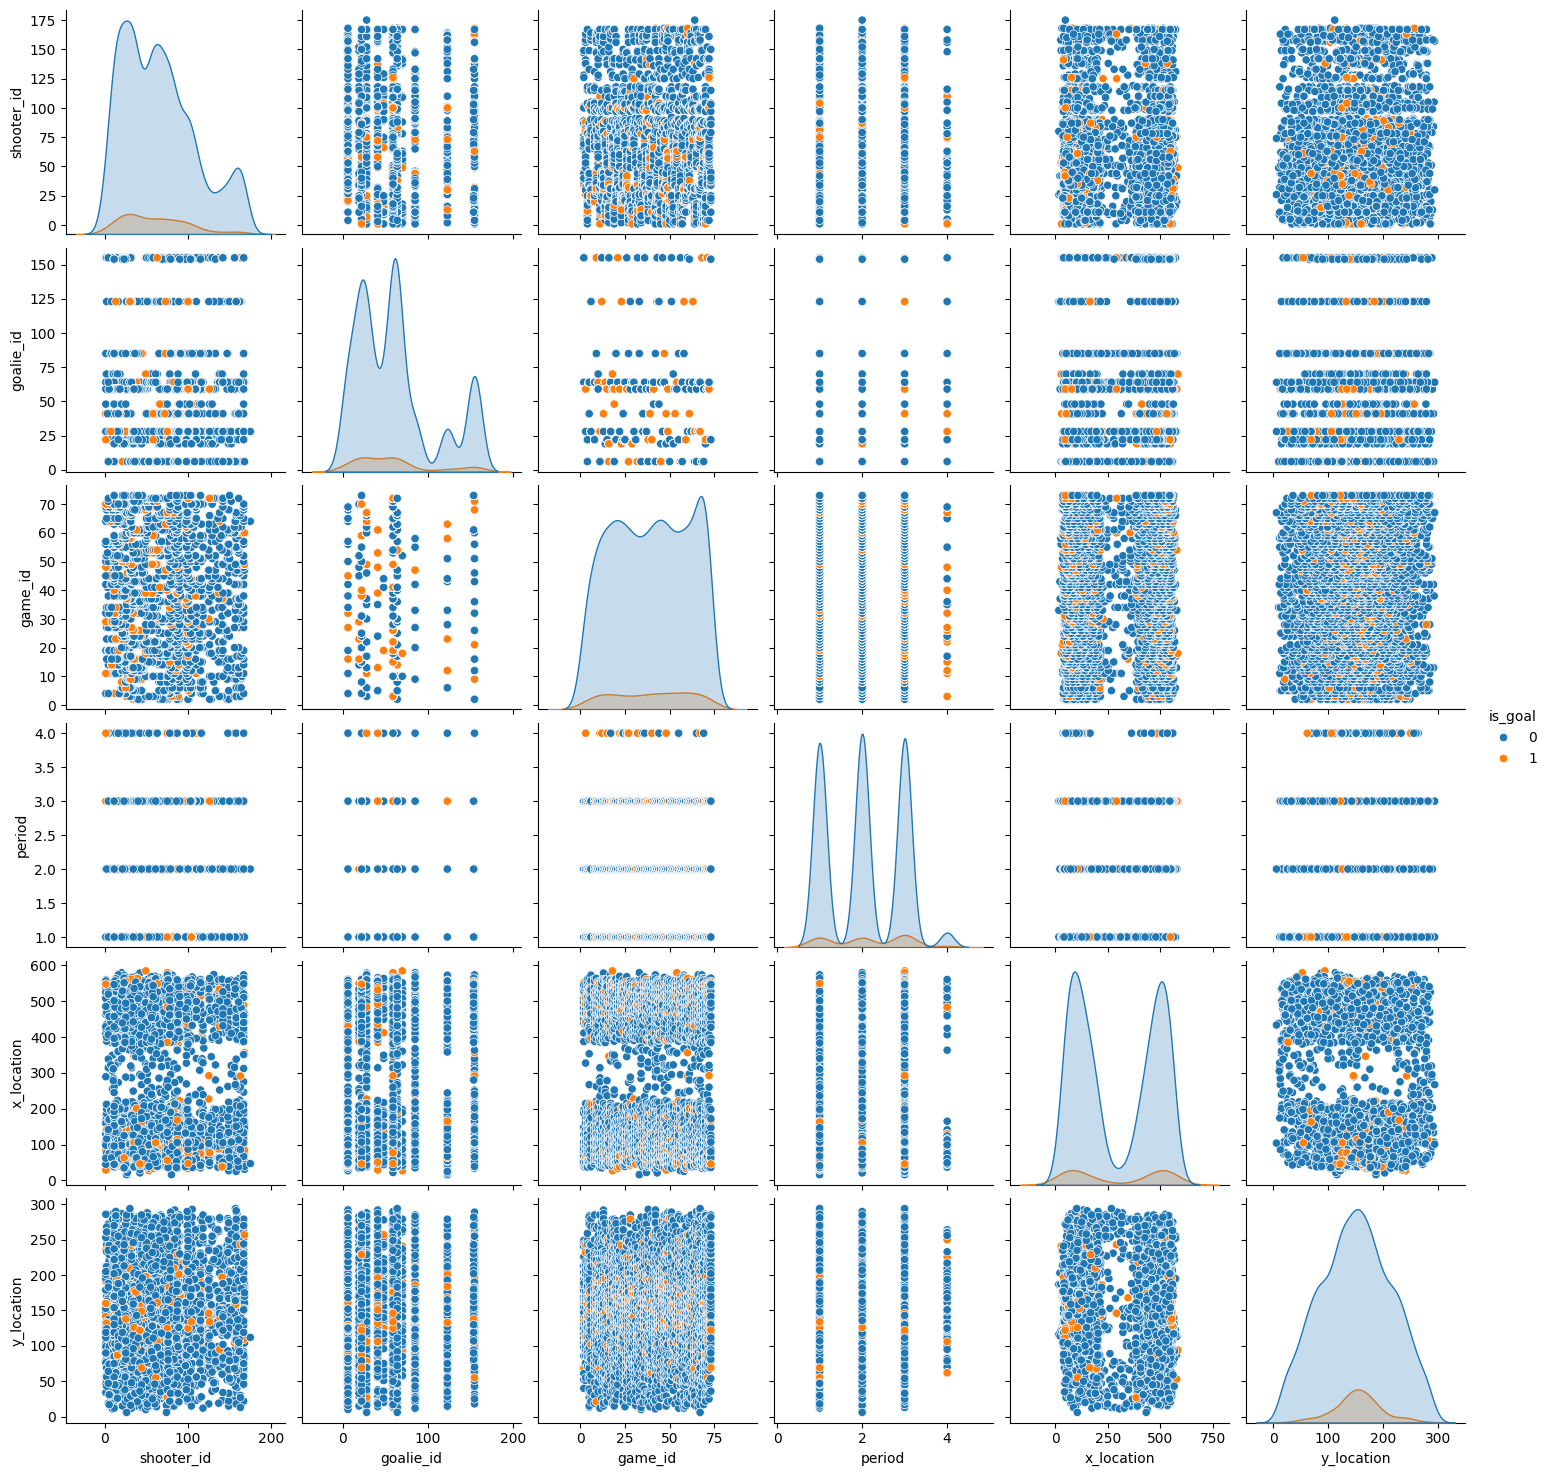

In [120]:
sns.pairplot(data=shots, hue="is_goal")

In [121]:
shots.head()

,shooter_id,goalie_id,game_id,period,time,is_goal,x_location,y_location,type,quality
0,44,64,2,1,0 days 01:29:00,0,448,63,Default,Non quality on net
1,36,64,2,1,0 days 03:30:00,0,549,182,Default,Non quality on net
2,46,64,2,1,0 days 03:36:00,0,387,225,Default,Non quality on net
3,86,64,2,1,0 days 04:57:00,0,541,134,Default,Quality on net
4,38,64,2,1,0 days 06:42:00,0,474,105,Default,Quality on net


In [122]:
shots.drop(["shooter_id", "goalie_id", "game_id", "time"], axis=1, inplace=True)

In [123]:
shots.drop("period", axis=1, inplace=True)

In [124]:
shots.head()

,is_goal,x_location,y_location,type,quality
0,0,448,63,Default,Non quality on net
1,0,549,182,Default,Non quality on net
2,0,387,225,Default,Non quality on net
3,0,541,134,Default,Quality on net
4,0,474,105,Default,Quality on net


In [125]:
type = pd.get_dummies(shots["type"], drop_first=True)

In [126]:
type.head()

,Default,Slap,Snap,Tip,Wrist
0,True,False,False,False,False
1,True,False,False,False,False
2,True,False,False,False,False
3,True,False,False,False,False
4,True,False,False,False,False


In [127]:
quality = pd.get_dummies(shots["quality"], drop_first=True)

In [128]:
shots = pd.concat([shots, type, quality], axis=1)

In [129]:
shots.head()

,is_goal,x_location,y_location,type,quality,Default,Slap,Snap,Tip,Wrist,Non quality on net,Quality goal,Quality on net
0,0,448,63,Default,Non quality on net,True,False,False,False,False,True,False,False
1,0,549,182,Default,Non quality on net,True,False,False,False,False,True,False,False
2,0,387,225,Default,Non quality on net,True,False,False,False,False,True,False,False
3,0,541,134,Default,Quality on net,True,False,False,False,False,False,False,True
4,0,474,105,Default,Quality on net,True,False,False,False,False,False,False,True


In [130]:
shots.drop(["type", "quality"], axis=1, inplace=True)

In [131]:
shots.head()

,is_goal,x_location,y_location,Default,Slap,Snap,Tip,Wrist,Non quality on net,Quality goal,Quality on net
0,0,448,63,True,False,False,False,False,True,False,False
1,0,549,182,True,False,False,False,False,True,False,False
2,0,387,225,True,False,False,False,False,True,False,False
3,0,541,134,True,False,False,False,False,False,False,True
4,0,474,105,True,False,False,False,False,False,False,True


In [132]:
from sklearn.preprocessing import StandardScaler

In [133]:
scaler = StandardScaler()

In [140]:
scaler.fit(shots.drop("is_goal", axis=1))

StandardScaler()

In [141]:
transformed = scaler.transform(shots.drop("is_goal", axis=1))

In [142]:
transformed

array([[ 0.80556585, -1.39451839,  1.12826235, ...,  1.00555091,
        -0.23588184, -0.85724226],
       [ 1.3291083 ,  0.49849898,  1.12826235, ...,  1.00555091,
        -0.23588184, -0.85724226],
       [ 0.48936694,  1.18253046,  1.12826235, ...,  1.00555091,
        -0.23588184, -0.85724226],
       ...,
       [ 1.29282318,  0.30760647, -0.88631868, ..., -0.99447974,
        -0.23588184,  1.16653138],
       [ 1.31355753,  0.81665315, -0.88631868, ...,  1.00555091,
        -0.23588184, -0.85724226],
       [-0.96203787, -0.63094836, -0.88631868, ..., -0.99447974,
        -0.23588184,  1.16653138]])

In [144]:
df_feat = pd.DataFrame(transformed, columns=shots.columns[1:])

In [145]:
from sklearn.model_selection import train_test_split

In [146]:
X = df_feat
y = shots["is_goal"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

In [147]:
from sklearn.neighbors import KNeighborsClassifier

In [148]:
knn = KNeighborsClassifier(n_neighbors=5)

In [149]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [150]:
predictions = knn.predict(X_test)

In [151]:
from sklearn.metrics import classification_report, confusion_matrix

In [152]:
print(confusion_matrix(y_test, predictions))

[[971   0]
 [  1  67]]


In [153]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       971
           1       1.00      0.99      0.99        68

    accuracy                           1.00      1039
   macro avg       1.00      0.99      1.00      1039
weighted avg       1.00      1.00      1.00      1039



In [154]:
error_rate = []

for i in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

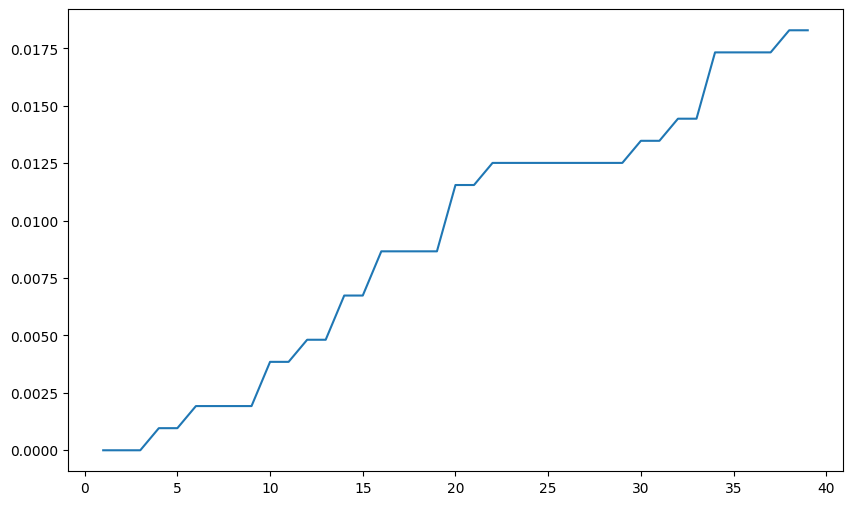

In [155]:
plt.figure(figsize=(10,6))
plt.plot(range(1,40),error_rate)

In [117]:
error_rate

[0.1472569778633301,
 0.09432146294513956,
 0.10202117420596728,
 0.08662175168431184,
 0.08854667949951876,
 0.0875842155919153,
 0.0904716073147257,
 0.0846968238691049,
 0.08662175168431184,
 0.0846968238691049,
 0.0846968238691049,
 0.0846968238691049,
 0.0846968238691049,
 0.0846968238691049,
 0.0846968238691049,
 0.0846968238691049,
 0.0846968238691049,
 0.0846968238691049,
 0.0846968238691049,
 0.0846968238691049,
 0.0846968238691049,
 0.0846968238691049,
 0.0846968238691049,
 0.0846968238691049,
 0.0846968238691049,
 0.0846968238691049,
 0.0846968238691049,
 0.0846968238691049,
 0.0846968238691049,
 0.0846968238691049,
 0.0846968238691049,
 0.0846968238691049,
 0.0846968238691049,
 0.0846968238691049,
 0.0846968238691049,
 0.0846968238691049,
 0.0846968238691049,
 0.0846968238691049,
 0.0846968238691049]